# **EJERCICIO PREPARATORIO SOLEMNE.**
**by *Guillermo Pinto*

Minería de Datos - UNAB
2025 **  





# Carga de librerías

In [51]:
# Librerías para manipulación y análisis de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas estadísticas y reducción de dimensionalidad
from scipy import stats
from sklearn.decomposition import PCA

# Separación de datos y preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# Modelos supervisados
from sklearn.linear_model import LinearRegression, LogisticRegression

# Métricas para regresión y clasificación
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score
)


# Carga de Datos

In [52]:
# Cargamos el dataset Advertising.
# El archivo debe estar disponible en el mismo entorno de ejecución del notebook.
# Variables predictoras: TV, Radio y Newspaper.
# Variable objetivo original: Sales.
df = pd.read_csv("Advertising.csv")

# Revisamos las primeras filas para verificar que la carga sea correcta.
df.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


# Análisis Exploratorio (EDA)

In [53]:
# Revisamos los nombres de las columnas y el tipo de dato de cada variable.
# Esta inspección permite identificar variables numéricas, categóricas
# y posibles problemas de formato antes de modelar.
print("Nombres de las columnas:", df.columns.tolist())
print("\nTipos de datos:\n", df.dtypes)


Nombres de las columnas: ['TV', 'Radio', 'Newspaper', 'Sales']

Tipos de datos:
 TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object


In [54]:
# Contamos cuántos valores distintos tiene cada columna.
# Una variable con muy pocos valores únicos podría corresponder a una
# variable categórica codificada numéricamente.
print("\nValores únicos por columna:\n", df.nunique())



Valores únicos por columna:
 TV           190
Radio        167
Newspaper    172
Sales        121
dtype: int64


In [55]:
# Resumen estadístico de las variables numéricas:
# cantidad de observaciones, media, desviación estándar, mínimos,
# máximos y cuartiles.
print("\nResumen estadístico:")
print(df.describe())



Resumen estadístico:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


In [56]:
# Estadísticos descriptivos de localización y dispersión.
# El coeficiente de variación permite comparar la dispersión relativa
# entre variables que están expresadas en escalas diferentes.
print("\nMedia:", df.mean(numeric_only=True))
print("Mediana:", df.median(numeric_only=True))
print("Desviación estándar:", df.std(numeric_only=True))
print("Rango (max - min):", df.max(numeric_only=True) - df.min(numeric_only=True))
print("Coeficiente de variación:", (df.std(numeric_only=True) / df.mean(numeric_only=True)) * 100)



Media: TV           147.0425
Radio         23.2640
Newspaper     30.5540
Sales         15.1305
dtype: float64
Mediana: TV           149.75
Radio         22.90
Newspaper     25.75
Sales         16.00
dtype: float64
Desviación estándar: TV           85.854236
Radio        14.846809
Newspaper    21.778621
Sales         5.283892
dtype: float64
Rango (max - min): TV           295.7
Radio         49.6
Newspaper    113.7
Sales         25.4
dtype: float64
Coeficiente de variación: TV           58.387362
Radio        63.818815
Newspaper    71.279115
Sales        34.922126
dtype: float64


Valores nulos por columna:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


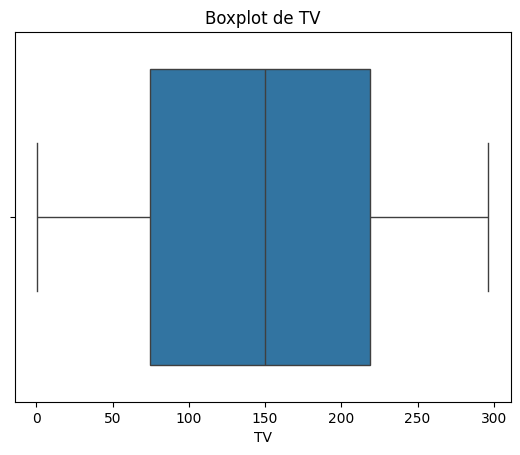

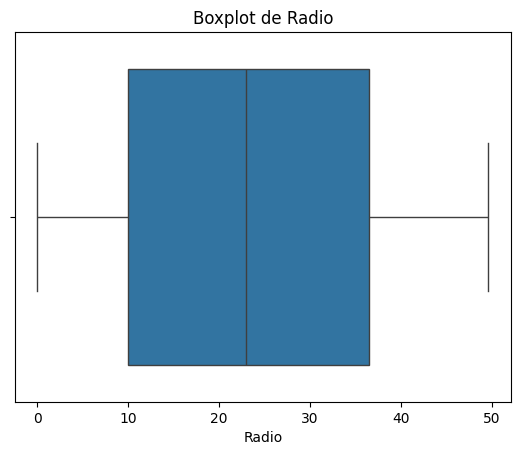

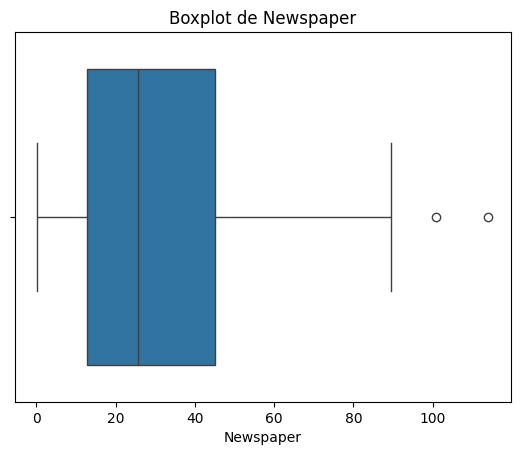

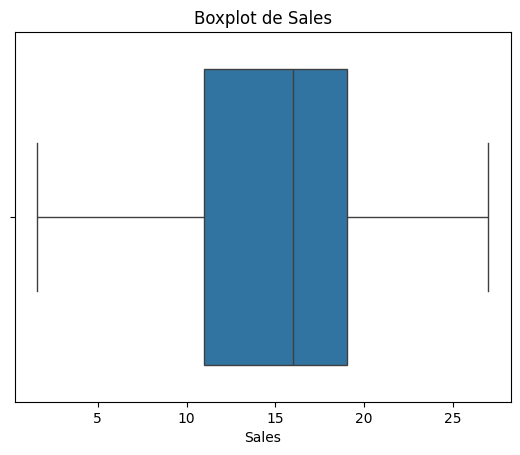

Número de outliers en TV según z-score: 0
Número de outliers en Radio según z-score: 0
Número de outliers en Newspaper según z-score: 2
Índices de outliers en Newspaper: [ 16 101]
Número de outliers en Sales según z-score: 0


In [57]:
# 1. Revisión de valores nulos.
# Antes de modelar debemos verificar si existen observaciones incompletas.
print("Valores nulos por columna:\n", df.isnull().sum())

# 2. Detección visual de posibles valores atípicos mediante boxplots.
for col in ['TV', 'Radio', 'Newspaper', 'Sales']:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

# 3. Detección numérica mediante z-score.
# Como regla práctica, |z| > 3 identifica observaciones alejadas
# más de tres desviaciones estándar respecto de la media.
for col in ['TV', 'Radio', 'Newspaper', 'Sales']:
    z = np.abs(stats.zscore(df[col]))
    outliers = np.where(z > 3)[0]
    print(f"Número de outliers en {col} según z-score:", len(outliers))
    if len(outliers) > 0:
        print(f"Índices de outliers en {col}:", outliers)


In [59]:
# Ejemplo de tratamiento de outliers detectados previamente.
outlier_indices = [16, 101]

# En lugar de eliminar las observaciones, reemplazamos los valores
# extremos de Newspaper por la mediana de la variable.
# Se trabaja sobre una copia para conservar intacto el DataFrame original.
mediana = df['Newspaper'].median()
df_imputado = df.copy()
df_imputado.loc[outlier_indices, 'Newspaper'] = mediana

print(f"Valores imputados en Newspaper (índices {outlier_indices}):")
print(df_imputado.loc[outlier_indices, 'Newspaper'])


Valores imputados en Newspaper (índices [16, 101]):
16     25.75
101    25.75
Name: Newspaper, dtype: float64


Los outliers pueden distorsionar los resultados de los análisis y modelos.
 Opciones comunes:
 - Eliminarlos si son errores o afectan demasiado.
 - Imputar valores si corresponde.
 - Transformar la variable para reducir su impacto.
 - Mantenerlos si son casos reales de interés.


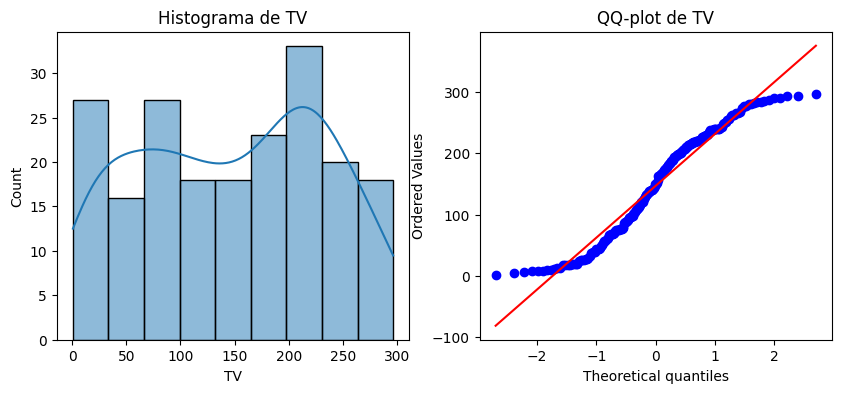

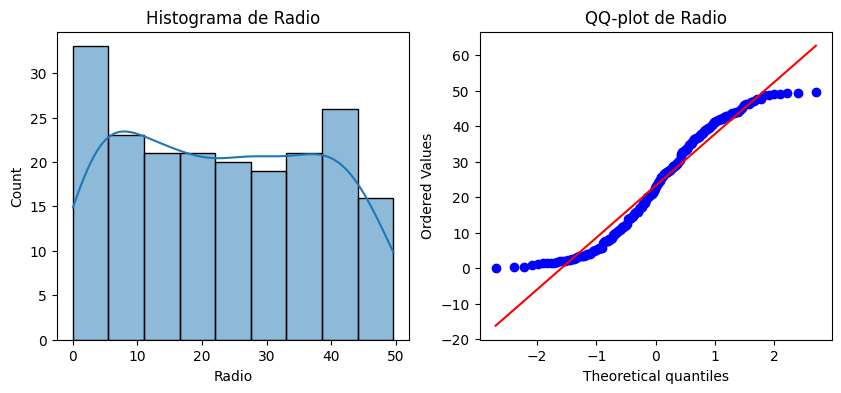

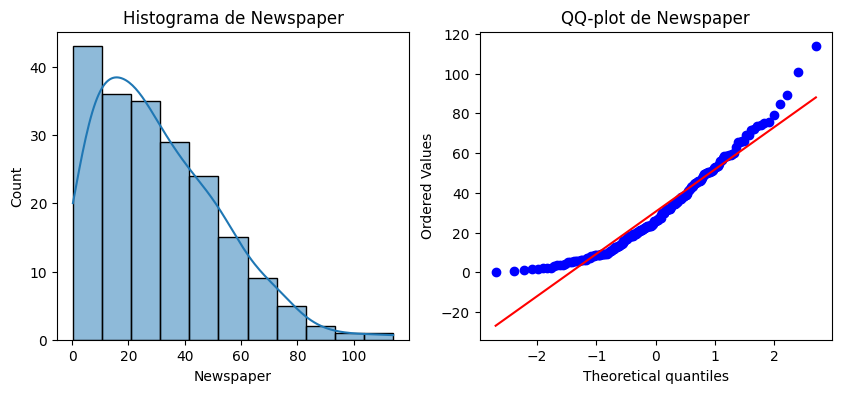

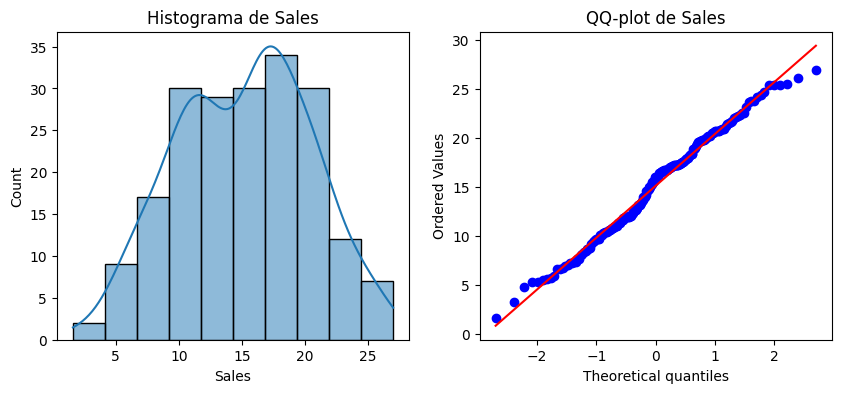

In [61]:
# Evaluamos visualmente la distribución de cada variable.
# El histograma muestra la forma de la distribución.
# El QQ-plot compara los cuantiles observados con los de una normal teórica.
for col in ['TV', 'Radio', 'Newspaper', 'Sales']:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {col}')

    stats.probplot(df[col], dist="norm", plot=axes[1])
    axes[1].set_title(f'QQ-plot de {col}')

    plt.tight_layout()
    plt.show()


In [62]:
# Pruebas formales de normalidad.
# Hipótesis nula (H0): la variable es compatible con una distribución normal.
# Como regla habitual, p-value <= 0.05 lleva a rechazar H0.
for col in ['TV', 'Radio', 'Newspaper', 'Sales']:
    shapiro = stats.shapiro(df[col])
    ks = stats.kstest(df[col], 'norm', args=(df[col].mean(), df[col].std()))
    print(
        f"{col} | Shapiro-Wilk p-value: {shapiro.pvalue:.3f} "
        f"| KS p-value: {ks.pvalue:.3f}"
    )


TV | Shapiro-Wilk p-value: 0.000 | KS p-value: 0.091
Radio | Shapiro-Wilk p-value: 0.000 | KS p-value: 0.113
Newspaper | Shapiro-Wilk p-value: 0.000 | KS p-value: 0.038
Sales | Shapiro-Wilk p-value: 0.076 | KS p-value: 0.201


¿Para qué sirven las pruebas de normalidad?

    Las pruebas de normalidad permiten evaluar si una variable sigue (o no) una distribución normal.
    Esto es importante porque muchos métodos estadísticos clásicos (regresión, ANOVA, tests paramétricos, etc.)
    suponen normalidad en los datos o en los residuos del modelo.

¿Por qué se usan Shapiro-Wilk y Kolmogorov-Smirnov?

    **Shapiro-Wilk**

    Es una de las pruebas más populares y poderosas para verificar normalidad en muestras pequeñas o medianas (n < 5000).

    Hipótesis nula: "La variable es normal".

    Si p-value > 0.05, no se rechaza la normalidad; si es menor, los datos se consideran no normales.

   ** Kolmogorov-Smirnov (KS)**

    Es una prueba de bondad de ajuste que compara la distribución empírica de los datos con la normal teórica.

    Menos potente para muestras pequeñas, pero útil como complemento.

    Interpretación igual: p-value > 0.05 indica que no se rechaza la normalidad.

¿Qué indica el resultado?

    Un p-value alto (> 0.05): los datos pueden considerarse normales.

    Un p-value bajo (≤ 0.05): los datos no siguen una distribución normal.

# Covarianza y Correlación

In [63]:
# Pearson mide principalmente asociación lineal.
# Spearman mide asociación monotónica basada en rangos y es menos sensible
# a relaciones no lineales y a ciertos valores extremos.
# La covarianza indica dirección conjunta, pero depende de la escala.
print("Matriz de correlación de Pearson:")
print(df.corr())

print("\nMatriz de correlación de Spearman:")
print(df.corr(method='spearman'))

print("\nMatriz de covarianza:")
print(df.cov())


Matriz de correlación de Pearson:
                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000

Matriz de correlación de Spearman:
                 TV     Radio  Newspaper     Sales
TV         1.000000  0.056123   0.050840  0.900996
Radio      0.056123  1.000000   0.316979  0.339949
Newspaper  0.050840  0.316979   1.000000  0.123027
Sales      0.900996  0.339949   0.123027  1.000000

Matriz de covarianza:
                    TV       Radio   Newspaper       Sales
TV         7370.949893   69.862492  105.919452  408.828044
Radio        69.862492  220.427743  114.496979   27.428189
Newspaper   105.919452  114.496979  474.308326   18.177390
Sales       408.828044   27.428189   18.177390   27.919517


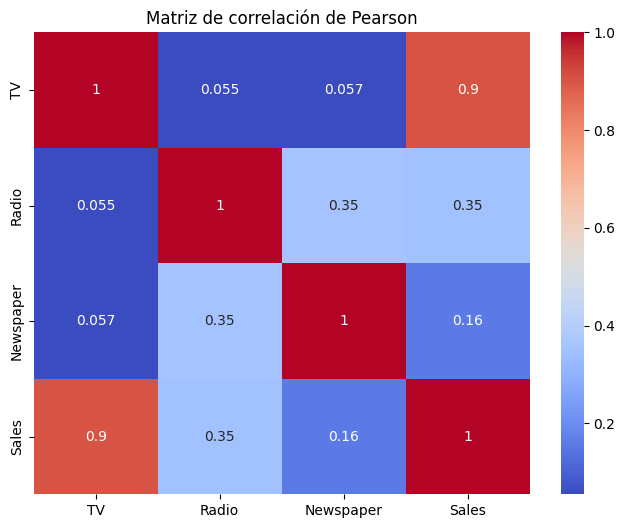

In [64]:
# Heatmap de correlación de Pearson.
# Valores cercanos a +1 indican asociación lineal positiva fuerte;
# cercanos a -1, asociación negativa fuerte; cercanos a 0, débil relación lineal.
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación de Pearson")
plt.show()


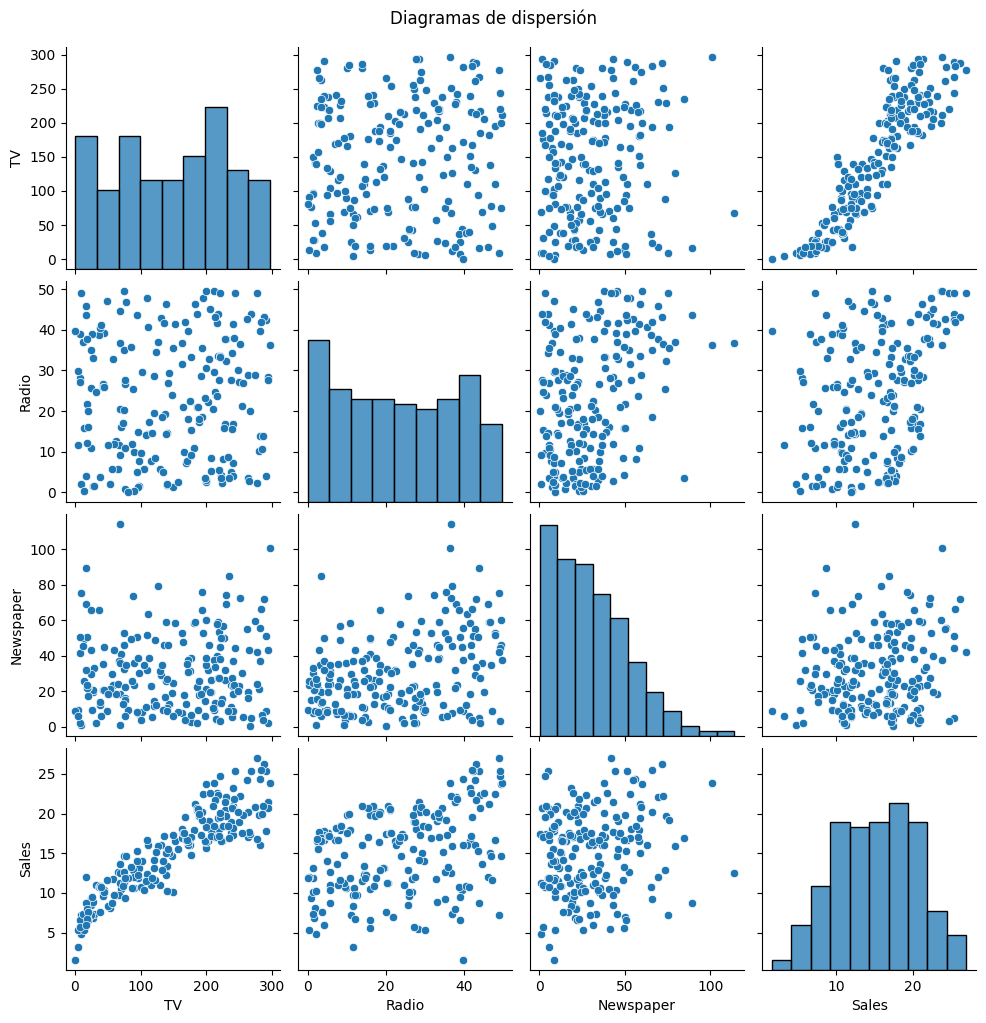

In [65]:
# Pairplot: permite revisar simultáneamente relaciones bivariadas
# y distribuciones individuales de todas las variables numéricas.
sns.pairplot(df)
plt.suptitle('Diagramas de dispersión', y=1.02)
plt.show()


# Reducción de Dimensionalidad

Varianza explicada por cada componente principal: [0.45695084 0.32775205 0.21529712]
Varianza explicada acumulada: [0.45695084 0.78470288 1.        ]


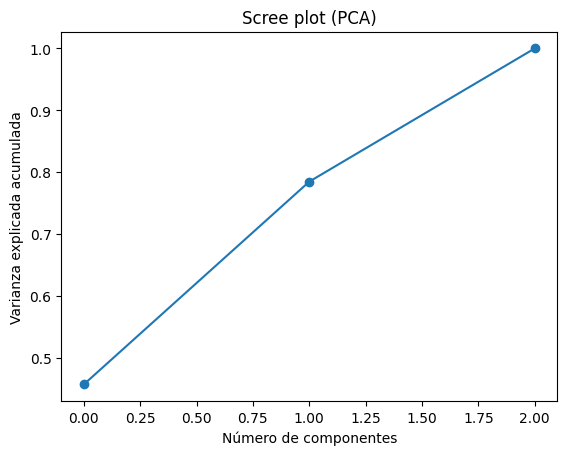

In [66]:
# PCA es sensible a la escala de las variables.
# Por ello estandarizamos TV, Radio y Newspaper antes de calcular
# los componentes principales.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['TV', 'Radio', 'Newspaper']])

# Conservamos tres componentes para observar cuánta varianza explica cada uno.
pca = PCA(n_components=3)
pca.fit(X_scaled)

print("Varianza explicada por cada componente principal:", pca.explained_variance_ratio_)
print("Varianza explicada acumulada:", np.cumsum(pca.explained_variance_ratio_))

# Scree plot: permite decidir cuántos componentes conservar
# según la varianza explicada acumulada.
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Scree plot (PCA)')
plt.grid(alpha=0.3)
plt.show()


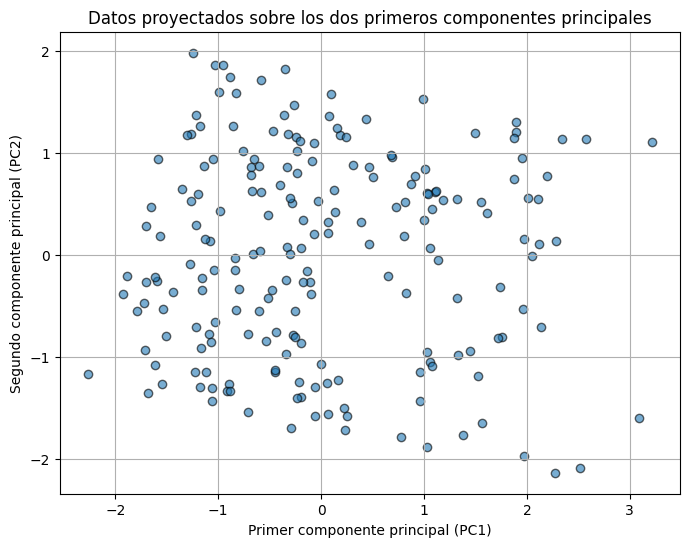

In [67]:
# Proyectamos los datos originales estandarizados al nuevo espacio PCA.
X_pca = pca.transform(X_scaled)

# Visualizamos solamente PC1 y PC2.
# La gráfica permite observar posibles agrupaciones o estructuras
# en un espacio de menor dimensionalidad.
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, edgecolor='k')
plt.xlabel('Primer componente principal (PC1)')
plt.ylabel('Segundo componente principal (PC2)')
plt.title('Datos proyectados sobre los dos primeros componentes principales')
plt.grid(True)
plt.show()


# Relaciones

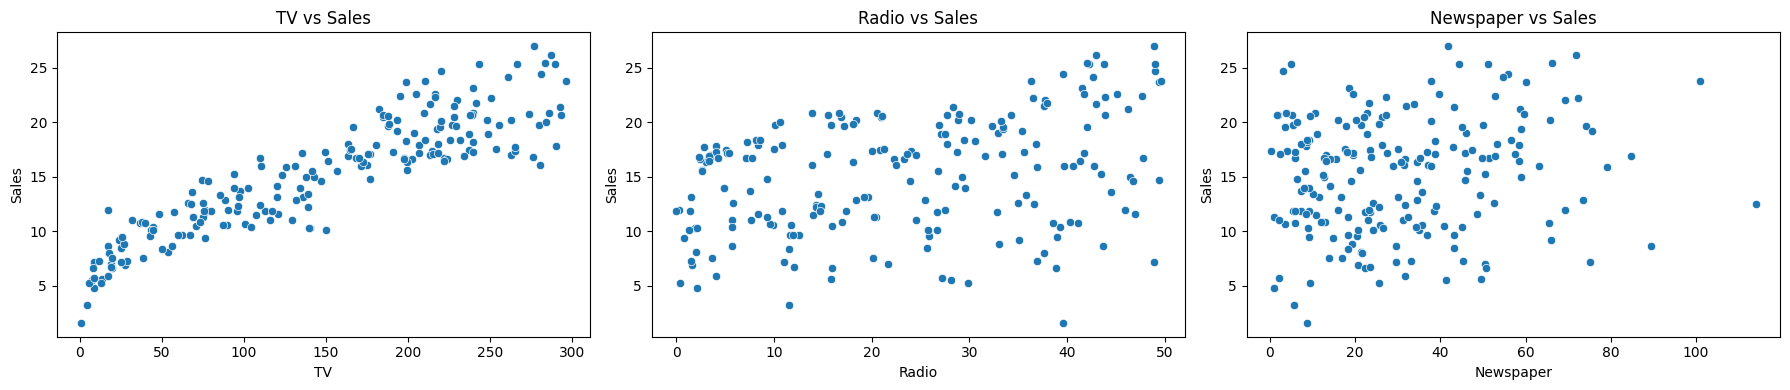

In [68]:
# Relación visual entre cada predictor y la variable objetivo Sales.
# Esto permite anticipar qué variables podrían tener mayor capacidad explicativa.
fig, axs = plt.subplots(1, 3, figsize=(18, 4))

sns.scatterplot(data=df, x='TV', y='Sales', ax=axs[0])
axs[0].set_title('TV vs Sales')

sns.scatterplot(data=df, x='Radio', y='Sales', ax=axs[1])
axs[1].set_title('Radio vs Sales')

sns.scatterplot(data=df, x='Newspaper', y='Sales', ax=axs[2])
axs[2].set_title('Newspaper vs Sales')

plt.tight_layout()
plt.show()


# Separar Datos para validar "aprendizaje" y Normalización

In [69]:
# Definimos las variables independientes (X) y la variable objetivo continua (y).
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Separamos los datos en entrenamiento (70%) y prueba (30%).
# random_state fija la semilla y permite reproducir exactamente la partición.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Ejemplo de normalización Min-Max.
# IMPORTANTE: el escalador se ajusta solamente con X_train para evitar
# fuga de información desde el conjunto de prueba.
# La regresión lineal puede entrenarse sin esta transformación,
# pero se conserva como demostración del procedimiento correcto.
scaler_mm = MinMaxScaler()
X_train_norm = scaler_mm.fit_transform(X_train)
X_test_norm = scaler_mm.transform(X_test)


# Modelo

In [70]:
# Creamos y entrenamos una regresión lineal múltiple.
# El modelo aprende la relación entre TV, Radio y Newspaper con Sales.
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Generamos predicciones únicamente sobre datos no utilizados durante el ajuste.
y_pred = modelo.predict(X_test)


In [71]:
# El intercepto representa el valor esperado de Sales cuando
# todos los predictores son 0.
# Cada coeficiente indica el cambio esperado en Sales ante un aumento
# de una unidad en ese predictor, manteniendo los demás constantes.
print("Intercepto:", modelo.intercept_)
for name, coef in zip(X.columns, modelo.coef_):
    print(f"Coeficiente para {name}: {coef:.3f}")


Intercepto: 4.743766701589685
Coeficiente para TV: 0.054
Coeficiente para Radio: 0.103
Coeficiente para Newspaper: 0.008


# Evaluación

Error cuadrático medio (MSE): 2.54
Raíz del error cuadrático medio (RMSE): 1.59
Coeficiente de determinación (R^2): 0.91


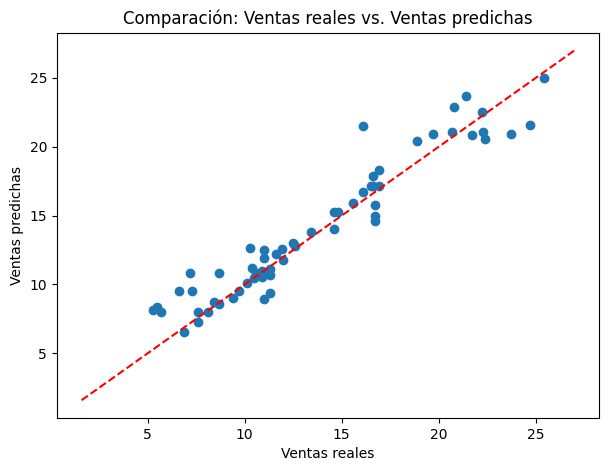

In [72]:
# Generamos las predicciones del conjunto de prueba.
y_pred = modelo.predict(X_test)

# MSE: promedio de los errores al cuadrado.
# RMSE: error en las mismas unidades de Sales.
# R²: proporción de variabilidad de Sales explicada por el modelo.
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Raíz del error cuadrático medio (RMSE): {rmse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")

# Comparamos valores reales y predichos.
# La línea diagonal representa el caso ideal y_pred = y_real.
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Ventas reales")
plt.ylabel("Ventas predichas")
plt.title("Comparación: Ventas reales vs. Ventas predichas")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()


**¿Qué es el R cuadrado (R²)?**

El R cuadrado (R²), o coeficiente de determinación, es una métrica que mide qué proporción de la variabilidad de la variable dependiente (por ejemplo, "Ventas" en nuestro caso) es explicada por el modelo (las variables independientes como "TV", "Radio", "Newspaper").

**¿Entre qué valores varía R²?**

*   R² varía entre 0 y 1 (aunque puede ser negativo en casos muy poco comunes, cuando el modelo es peor que la media).
*   R² = 1: El modelo explica el 100% de la variabilidad de la variable dependiente. Todas las predicciones caen exactamente sobre los valores reales.
*   R² = 0: El modelo no explica nada de la variabilidad. Es tan malo como predecir siempre la media de la variable dependiente.
*   R² < 0: Sucede solo si el modelo es peor que predecir la media, por ejemplo, en regresión sin intercepto o con datos mal ajustados.


**¿Cómo se interpreta?**

Ejemplo: Si obtienes un R² = 0.85, eso significa que el 85% de la variabilidad en las ventas se explica por el gasto en publicidad en TV, radio y periódico. El 15% restante se debe a otras causas no incluidas en el modelo o al azar.

**En resumen**

R² cercano a 1: Buen ajuste (el modelo explica casi toda la variabilidad).

R² cercano a 0: Mal ajuste (el modelo explica muy poco).

R² negativo: Modelo peor que usar la media (cuidado, suele indicar errores de modelado).

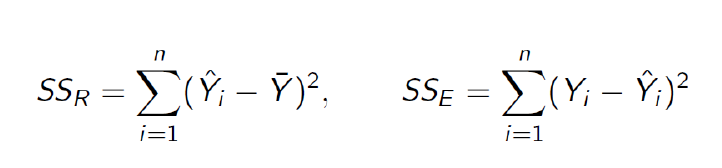

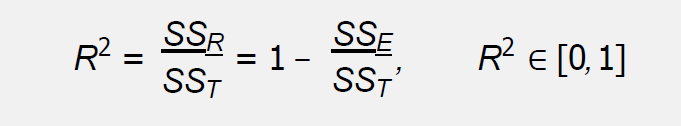

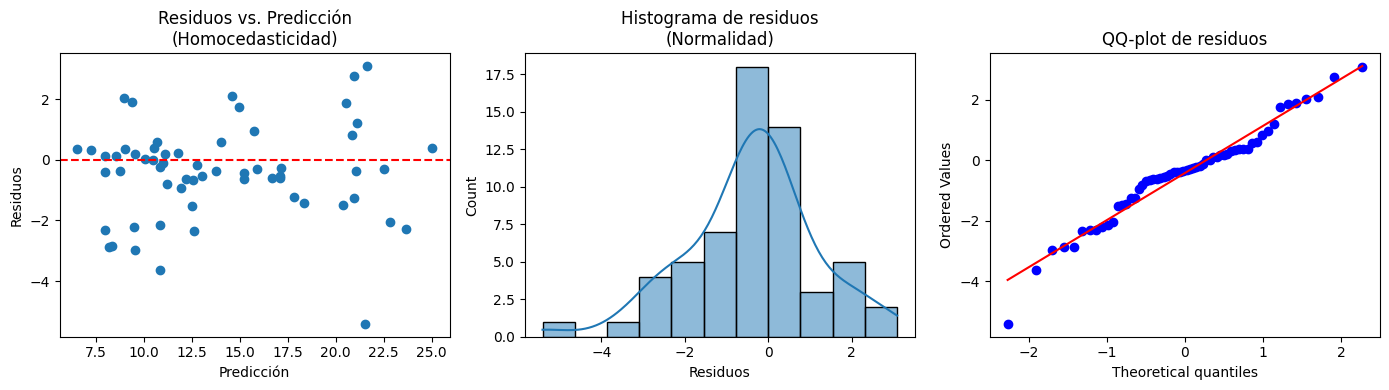

In [73]:
# Diagnóstico gráfico de los residuos del modelo lineal.
# Residuo = valor real - valor predicho.
residuos = y_test - y_pred

plt.figure(figsize=(14, 4))

# 1. Residuos vs predicción:
# permite revisar linealidad y homocedasticidad.
plt.subplot(1, 3, 1)
plt.scatter(y_pred, residuos)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs. Predicción\n(Homocedasticidad)')
plt.xlabel('Predicción')
plt.ylabel('Residuos')

# 2. Histograma:
# permite observar si los residuos son aproximadamente simétricos/normales.
plt.subplot(1, 3, 2)
sns.histplot(residuos, kde=True)
plt.title('Histograma de residuos\n(Normalidad)')
plt.xlabel('Residuos')

# 3. QQ-plot:
# si los puntos siguen aproximadamente la diagonal,
# la normalidad de los residuos resulta razonable.
plt.subplot(1, 3, 3)
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('QQ-plot de residuos')

plt.tight_layout()
plt.show()


1. Residuos vs. Predicción (Homocedasticidad y linealidad)
          ¿Qué muestra?
          Cada punto es un residuo para una predicción dada.
          La línea roja (en 0) marca el lugar donde el residuo sería cero (predicción perfecta).

          ¿Qué buscamos?

          Homocedasticidad:
          Queremos que la dispersión de los residuos sea similar a lo largo de todas las predicciones (nube horizontal, sin forma de abanico o patrón).
          Si los residuos se dispersan más en algunos lugares, el modelo viola la homocedasticidad y podría ser inadecuado.

          Linealidad:
          No debe haber patrones (curvas, tendencias); si los hay, tal vez el modelo debería ser no lineal.

2. Histograma de residuos (Normalidad de errores)
          ¿Qué muestra?
          La distribución de los residuos.

          ¿Qué buscamos?
          Una forma aproximadamente de campana (normal). Si es muy asimétrico o tiene colas largas, el supuesto de normalidad no se cumple, lo que puede afectar las inferencias (tests de hipótesis e intervalos de confianza).

3. Q-Q Plot de residuos (Normalidad de errores)
          ¿Qué muestra?
          Compara los residuos observados con los que esperaríamos bajo una distribución normal.

          ¿Qué buscamos?
          Los puntos deben alinearse lo más cerca posible de la línea diagonal.

          Si los puntos se apartan mucho (especialmente en los extremos), la distribución no es normal.

In [74]:
# Prueba formal de normalidad aplicada a los residuos.
# H0: los residuos son compatibles con una distribución normal.
sw_res = stats.shapiro(residuos)
print(f"Shapiro-Wilk para residuos: p-value = {sw_res.pvalue:.3f}")

# Interpretación usual:
# p-value > 0.05  -> no se rechaza la normalidad.
# p-value <= 0.05 -> existe evidencia para rechazar la normalidad.


Shapiro-Wilk para residuos: p-value = 0.111


**¿Para qué sirve la prueba de Shapiro-Wilk en residuos?**
La prueba de Shapiro-Wilk es un test estadístico de normalidad.
Se usa para evaluar si una muestra (en este caso, los residuos del modelo) provienen de una distribución normal.

¿Por qué es importante?
En la regresión lineal clásica, se asume que los residuos (errores) son normales.

# Intervalos de Confianza

¿Para qué sirven los intervalos de confianza?

**Estimación de la incertidumbre**
Los intervalos de confianza nos permiten saber qué tan seguros estamos sobre el valor estimado de un parámetro o una predicción. No nos conformamos solo con el valor “puntual” (por ejemplo, la predicción de ventas), sino que cuantificamos la posible variabilidad debida al azar, al tamaño muestral o al error del modelo.

**Comunican precisión**
Un intervalo angosto significa que la estimación es precisa; un intervalo ancho indica mayor incertidumbre. Esto es esencial para la toma de decisiones informadas en ingeniería, economía, ciencia de datos, etc.

In [75]:
import statsmodels.api as sm

# statsmodels permite obtener inferencia estadística adicional,
# como intervalos de confianza para coeficientes y predicciones.

# Agregamos explícitamente la constante (intercepto) y ajustamos OLS.
X_train_const = sm.add_constant(X_train)
modelo_sm = sm.OLS(y_train, X_train_const).fit()

# Intervalos de confianza al 95% para los coeficientes.
print("Intervalos de confianza para los coeficientes (95%):")
print(modelo_sm.conf_int(alpha=0.05))

# Seleccionamos una observación del conjunto de prueba como ejemplo.
X_pred = X_test.iloc[[0]]

# Agregamos la constante y conservamos el mismo orden de columnas
# utilizado durante el entrenamiento.
X_pred_const = pd.DataFrame(
    np.c_[np.ones((X_pred.shape[0], 1)), X_pred.values],
    columns=X_train_const.columns
)

# Obtenemos la predicción y sus intervalos.
pred_result = modelo_sm.get_prediction(X_pred_const)

# Intervalo para la media esperada de Sales.
ci_mean = pred_result.summary_frame(alpha=0.05)[['mean_ci_lower', 'mean_ci_upper']]
print("\nIntervalo de confianza para el valor esperado (media) de Ŷᵢ (95%):")
print(ci_mean)

# Intervalo para una nueva observación individual.
# Normalmente es más ancho porque incorpora variabilidad adicional.
ci_obs = pred_result.summary_frame(alpha=0.05)[['obs_ci_lower', 'obs_ci_upper']]
print("\nIntervalo de predicción para una observación futura Y₀ (95%):")
print(ci_obs)


Intervalos de confianza para los coeficientes (95%):
                  0         1
const      3.953002  5.534532
TV         0.050163  0.057014
Radio      0.081824  0.123589
Newspaper -0.006810  0.022673

Intervalo de confianza para el valor esperado (media) de Ŷ_i (95%):
   mean_ci_lower  mean_ci_upper
0      16.733825      17.586013

Intervalo de confianza para una observación futura Y₀ (95%):
   obs_ci_lower  obs_ci_upper
0     13.752332     20.567506


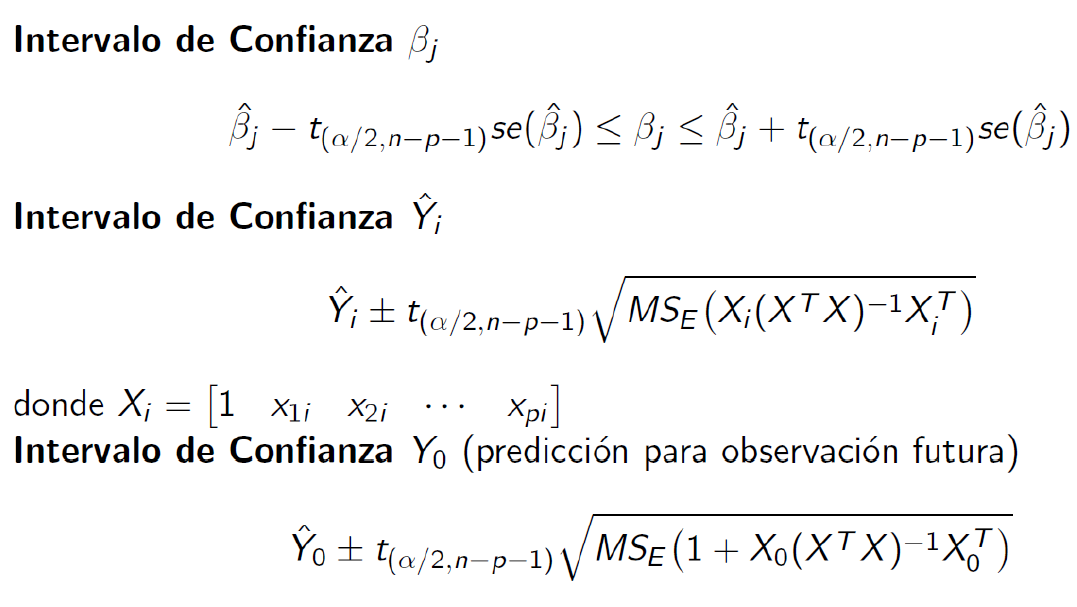

¿Qué se descubre con los intervalos de confianza en regresión?

**Para los coeficientes (𝛽𝑗 ):**

El intervalo de confianza para cada coeficiente nos dice en qué rango podría estar el valor verdadero del parámetro (por ejemplo, cuánto impacta realmente el gasto en TV sobre las ventas) si repitiéramos el experimento muchas veces.

Si el intervalo de confianza de un coeficiente incluye el cero, entonces ese predictor podría no ser relevante estadísticamente.

Si no incluye el cero, el predictor sí tiene un efecto significativo.

**Para la media predicha (𝑌𝑖):**
El intervalo nos dice con qué precisión podemos estimar el valor medio esperado de la variable dependiente (por ejemplo, el valor promedio de ventas para una combinación específica de publicidad).

**Para una observación futura (𝑌0 ):**

Aquí, el intervalo **es más amplio** porque incluye la variabilidad natural de los datos. Responde: “Si mañana observo un caso nuevo, ¿en qué rango podría caer realmente el resultado?”

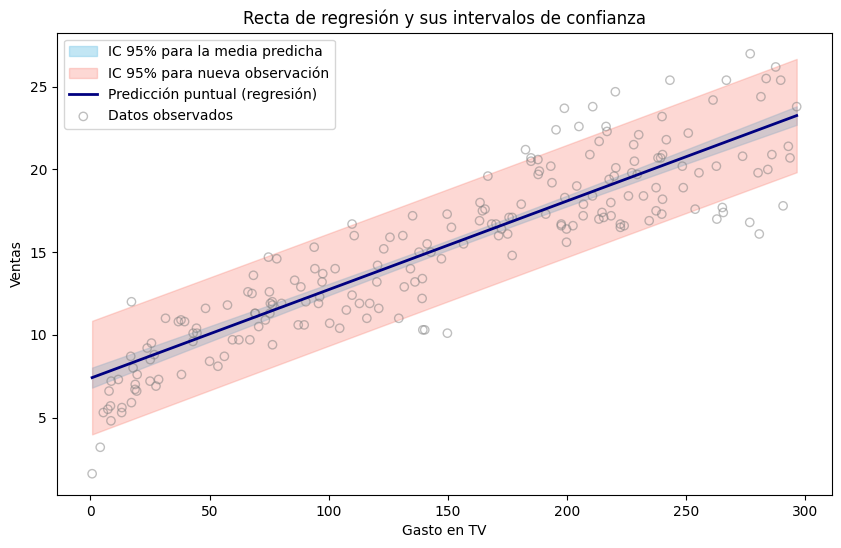

In [76]:
# Para visualizar el modelo en 2D usamos TV en el eje X y mantenemos
# Radio y Newspaper fijos en sus respectivos promedios.
tv_range = np.linspace(X['TV'].min(), X['TV'].max(), 100)
radio_mean = X['Radio'].mean()
news_mean = X['Newspaper'].mean()

# Construimos los datos sobre los que se calcularán las predicciones.
X_pred_all = pd.DataFrame({
    'const': 1,
    'TV': tv_range,
    'Radio': radio_mean,
    'Newspaper': news_mean
})

# Predicciones e intervalos al 95%.
preds = modelo_sm.get_prediction(X_pred_all)
pred_frame = preds.summary_frame(alpha=0.05)

plt.figure(figsize=(10, 6))

# Banda angosta: incertidumbre sobre la media esperada.
plt.fill_between(
    tv_range,
    pred_frame['mean_ci_lower'],
    pred_frame['mean_ci_upper'],
    color='skyblue',
    alpha=0.5,
    label='IC 95% para la media predicha'
)

# Banda ancha: incertidumbre de una nueva observación individual.
plt.fill_between(
    tv_range,
    pred_frame['obs_ci_lower'],
    pred_frame['obs_ci_upper'],
    color='salmon',
    alpha=0.3,
    label='Intervalo 95% para nueva observación'
)

# Predicción puntual del modelo.
plt.plot(
    tv_range,
    pred_frame['mean'],
    color='navy',
    lw=2,
    label='Predicción puntual (regresión)'
)

# Datos observados.
plt.scatter(
    X['TV'],
    y,
    facecolors='none',
    edgecolors='grey',
    alpha=0.5,
    label='Datos observados'
)

plt.xlabel('Gasto en TV')
plt.ylabel('Ventas')
plt.title('Recta de regresión y sus intervalos de confianza')
plt.legend()
plt.show()



# Regresión Logística con los mismos datos

La **regresión logística** se utiliza cuando la variable objetivo es **categórica**.  
En este dataset, `Sales` es una variable continua, por lo que no puede utilizarse directamente como objetivo de una regresión logística.

Para conservar **los mismos datos y los mismos predictores** (`TV`, `Radio` y `Newspaper`), transformaremos `Sales` en una variable binaria:

- **0 = Venta baja**
- **1 = Venta alta**

El umbral será la **mediana de `Sales` calculada únicamente con los datos de entrenamiento**. Esto mantiene separada la información del conjunto de prueba y evita fuga de información.

Además, utilizaremos exactamente la misma partición `X_train` / `X_test` creada anteriormente.



## Construcción de la variable objetivo binaria


In [ ]:

# Calculamos el umbral usando SOLO y_train.
# Esto evita utilizar información del conjunto de prueba para definir las clases.
umbral_sales = y_train.median()

# Convertimos la variable continua Sales en una variable binaria.
# 1 = venta alta (Sales >= mediana de entrenamiento)
# 0 = venta baja (Sales < mediana de entrenamiento)
y_train_clas = (y_train >= umbral_sales).astype(int)
y_test_clas = (y_test >= umbral_sales).astype(int)

print(f"Umbral de ventas (mediana de entrenamiento): {umbral_sales:.2f}")

print("\nDistribución de clases en entrenamiento:")
print(y_train_clas.value_counts().sort_index().rename(index={0: 'Venta baja', 1: 'Venta alta'}))

print("\nDistribución de clases en prueba:")
print(y_test_clas.value_counts().sort_index().rename(index={0: 'Venta baja', 1: 'Venta alta'}))



## Entrenamiento del modelo

La regresión logística estima la **probabilidad de pertenecer a la clase positiva**.  
En este caso, la clase positiva corresponde a **Venta alta (1)**.

Se incorpora `StandardScaler` dentro de un `Pipeline`. De esta forma, el escalamiento se aprende únicamente con los datos de entrenamiento y luego se aplica al conjunto de prueba.


In [ ]:

# Pipeline:
# 1) Estandariza las variables predictoras.
# 2) Entrena la regresión logística con los datos ya transformados.
modelo_logistico = Pipeline([
    ('scaler', StandardScaler()),
    ('logistica', LogisticRegression(max_iter=1000, random_state=42))
])

# Entrenamiento.
modelo_logistico.fit(X_train, y_train_clas)

# Predicción de clase usando el umbral por defecto de 0.5.
y_pred_clas = modelo_logistico.predict(X_test)

# Probabilidad estimada de la clase positiva (Venta alta = 1).
# Estas probabilidades se utilizarán para construir la curva ROC.
y_prob_clas = modelo_logistico.predict_proba(X_test)[:, 1]



## Matriz de confusión

La matriz de confusión resume los aciertos y errores del clasificador:

- **TN (verdadero negativo):** venta baja correctamente clasificada.
- **FP (falso positivo):** venta baja clasificada como alta.
- **FN (falso negativo):** venta alta clasificada como baja.
- **TP (verdadero positivo):** venta alta correctamente clasificada.


In [ ]:

# Calculamos la matriz de confusión.
cm = confusion_matrix(y_test_clas, y_pred_clas)

# La mostramos gráficamente para facilitar su interpretación.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Venta baja', 'Venta alta']
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión - Regresión logística')
plt.show()



## Reporte de métricas

Las métricas principales son:

- **Accuracy:** proporción total de predicciones correctas.
- **Precision:** de los casos predichos como venta alta, cuántos realmente lo eran.
- **Recall (sensibilidad):** de las ventas altas reales, cuántas fueron detectadas.
- **F1-score:** media armónica entre precision y recall.

El reporte también muestra el **support**, es decir, la cantidad de observaciones de cada clase.


In [ ]:

# Accuracy global del modelo.
accuracy = accuracy_score(y_test_clas, y_pred_clas)
print(f"Accuracy: {accuracy:.3f}\n")

# Reporte completo por clase.
print("Reporte de clasificación:")
print(
    classification_report(
        y_test_clas,
        y_pred_clas,
        target_names=['Venta baja', 'Venta alta'],
        digits=3
    )
)



## Curva ROC y AUC

La curva **ROC (Receiver Operating Characteristic)** evalúa el comportamiento del clasificador para distintos umbrales de decisión.

- Eje X: **False Positive Rate (FPR)**.
- Eje Y: **True Positive Rate (TPR o sensibilidad)**.
- La diagonal representa un clasificador aleatorio.
- Cuanto más se acerque la curva a la esquina superior izquierda, mejor es la capacidad de discriminación.

El **AUC (Area Under the Curve)** resume la curva ROC en un solo valor:

- **AUC = 0.5:** comportamiento similar al azar.
- **AUC cercano a 1:** excelente capacidad de separar ambas clases.


In [ ]:

# Calculamos los puntos de la curva ROC a partir de las probabilidades.
fpr, tpr, thresholds = roc_curve(y_test_clas, y_prob_clas)

# Área bajo la curva ROC.
auc = roc_auc_score(y_test_clas, y_prob_clas)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f'Regresión logística (AUC = {auc:.3f})')

# Referencia de un clasificador aleatorio.
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio (AUC = 0.5)')

plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Regresión logística')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"AUC: {auc:.3f}")



### Interpretación final

La regresión lineal y la regresión logística responden preguntas distintas utilizando los mismos predictores:

- La **regresión lineal** estima un valor continuo de `Sales`.
- La **regresión logística** estima la probabilidad de que una observación pertenezca a la categoría **Venta alta**.

Por esta razón, las métricas de evaluación también cambian: en regresión lineal utilizamos medidas como **RMSE y R²**, mientras que en clasificación utilizamos **matriz de confusión, precision, recall, F1-score, ROC y AUC**.
